# Library and Package

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.feature_selection import SelectKBest, chi2

# Load the Dataset

(12684, 26)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12684 non-null  object
 1   passanger             12684 non-null  object
 2   weather               12684 non-null  object
 3   temperature           12684 non-null  int64 
 4   time                  12684 non-null  object
 5   coupon                12684 non-null  object
 6   expiration            12684 non-null  object
 7   gender                12684 non-null  object
 8   age                   12684 non-null  object
 9   maritalStatus         12684 non-null  object
 10  has_children          12684 non-null  int64 
 11  education             12684 non-null  object
 12  occupation            12684 non-null  object
 13  income                12684 non-null  object
 14  car                   108 non-null    object
 15  Bar                   12

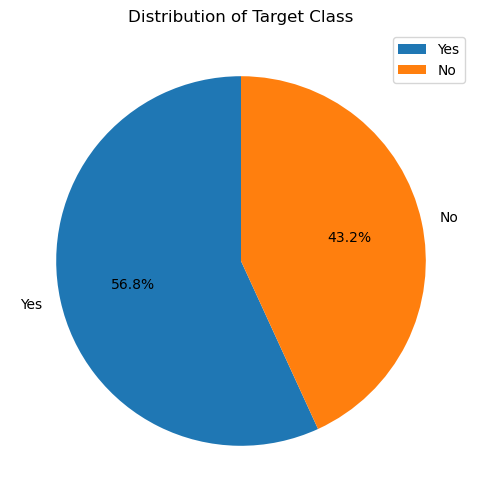

In [2]:
df = pd.read_csv('in-vehicle-coupon-recommendation.csv')
print(df.shape)

df.info()

#check missing values
df.isnull().sum()

unique_counts = df.nunique()

print(unique_counts)

#check distribution of target class
class_counts = df['Y'].value_counts()

class_counts.plot.pie(
    autopct='%1.1f%%',  
    startangle=90,      
    figsize=(6, 6),
    labels= ['Yes', 'No']
    
)

plt.title('Distribution of Target Class') 
plt.ylabel('') 

plt.legend()

plt.show()

# Clean Column Names

In [3]:
#noted that this function is used in
def clean_columns(df):
    df.columns = [str(col) for col in df.columns]
    df.columns = [
        re.sub(r'[^A-Za-z0-9_]', '_', col)
        for col in df.columns
    ]
    df.columns = [
        re.sub(r'_+', '_', col).strip('_')
        for col in df.columns
    ]

    return df

# Data Splitting

In [4]:
#split the features and the target variables
X = df.drop(columns=['car','occupation', 'Y'])
y = df['Y']

#train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Handling Missing Values

In [5]:
#fill the missing value
cols = ['Bar', 'CoffeeHouse', 'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50']

for col in cols:
    df[col] = df[col].fillna(df[col].mode()[0]) #mode imputation method

for col in cols:
    #calculate the mode using only the training data
    mode_val = X_train[col].mode()[0]
    
    #fill missing values in both sets using that training mode
    X_train[col] = X_train[col].fillna(mode_val)
    X_test[col] = X_test[col].fillna(mode_val)

X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10147 entries, 9553 to 11504
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           10147 non-null  object
 1   passanger             10147 non-null  object
 2   weather               10147 non-null  object
 3   temperature           10147 non-null  int64 
 4   time                  10147 non-null  object
 5   coupon                10147 non-null  object
 6   expiration            10147 non-null  object
 7   gender                10147 non-null  object
 8   age                   10147 non-null  object
 9   maritalStatus         10147 non-null  object
 10  has_children          10147 non-null  int64 
 11  education             10147 non-null  object
 12  income                10147 non-null  object
 13  Bar                   10147 non-null  object
 14  CoffeeHouse           10147 non-null  object
 15  CarryAway             10147 non-null  

# Encoding Categorical Features

In [6]:
#define ordinal and nominal columns
nom_cols = ['destination', 'passanger', 'weather', 'time', 'coupon', 'expiration', 'gender', 'maritalStatus']
ord_cols = ['age', 'education', 'income', 'Bar', 'CoffeeHouse', 'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50']

#intialize encoders
ohe_enc = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
ord_enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

#==================process training data===================
#nominal label
X_train_nom_array = ohe_enc.fit_transform(X_train[nom_cols])
X_train_nom_df = pd.DataFrame(X_train_nom_array, columns=ohe_enc.get_feature_names_out(), index=X_train.index)

#ordinal label
X_train_ord_array = ord_enc.fit_transform(X_train[ord_cols])
X_train_ord_df = pd.DataFrame(X_train_ord_array, columns=ord_cols, index=X_train.index)

#merge them back
X_train = pd.concat([X_train_nom_df, X_train_ord_df], axis=1)

#==================process testing data====================
#nominal label
X_test_nom_array = ohe_enc.transform(X_test[nom_cols])
X_test_nom_df = pd.DataFrame(X_test_nom_array, columns=ohe_enc.get_feature_names_out(), index=X_test.index)

#ordinal label
X_test_ord_array = ord_enc.transform(X_test[ord_cols])
X_test_ord_df = pd.DataFrame(X_test_ord_array, columns=ord_cols, index=X_test.index)

#merge them back
X_test = pd.concat([X_test_nom_df, X_test_ord_df], axis=1)

print(X_train.shape)
print(X_test.shape)

print(X_train.head)


(10147, 29)
(2537, 29)
<bound method NDFrame.head of        destination_No Urgent Place  destination_Work  passanger_Friend(s)  \
9553                           0.0               1.0                  0.0   
1394                           1.0               0.0                  1.0   
552                            1.0               0.0                  1.0   
8377                           0.0               0.0                  0.0   
1353                           1.0               0.0                  1.0   
...                            ...               ...                  ...   
1062                           1.0               0.0                  1.0   
2812                           1.0               0.0                  0.0   
11414                          1.0               0.0                  1.0   
546                            1.0               0.0                  1.0   
11504                          1.0               0.0                  0.0   

       passanger_Kid(s

# Feature Selection

In [7]:
selector = SelectKBest(score_func=chi2, k=20)

X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

selected_features = X_train.columns[selector.get_support()]
print(selected_features)

Index(['destination_No Urgent Place', 'destination_Work',
       'passanger_Friend(s)', 'weather_Snowy', 'weather_Sunny', 'time_10PM',
       'time_2PM', 'time_7AM', 'coupon_Carry out & Take away',
       'coupon_Coffee House', 'coupon_Restaurant(20-50)',
       'coupon_Restaurant(<20)', 'expiration_2h', 'maritalStatus_Single',
       'age', 'education', 'Bar', 'CoffeeHouse', 'CarryAway',
       'Restaurant20To50'],
      dtype='object')


# Save the preprocessed data

In [8]:
X_train_selected = pd.DataFrame(X_train_selected, columns=selected_features)
X_test_selected = pd.DataFrame(X_test_selected, columns=selected_features)

train_final = pd.concat([X_train_selected, y_train.reset_index(drop=True)], axis=1)
test_final = pd.concat([X_test_selected, y_test.reset_index(drop=True)], axis=1)

train_final.to_csv("train_data.csv", index=False)
test_final.to_csv("test_data.csv", index=False)